In [1]:
from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

# Jury selection in Alameda County

In [2]:
jury = Table().with_columns(
    'ethnicity', make_array('asian', 'black', 'latino', 'white', 'other'),
    'eligible', make_array (.15, .18, .12, .54, .01),
    'panel', make_array(.26, .08, .08, .54, .04)
)
jury

ethnicity,eligible,panel
asian,0.15,0.26
black,0.18,0.08
latino,0.12,0.08
white,0.54,0.54
other,0.01,0.04


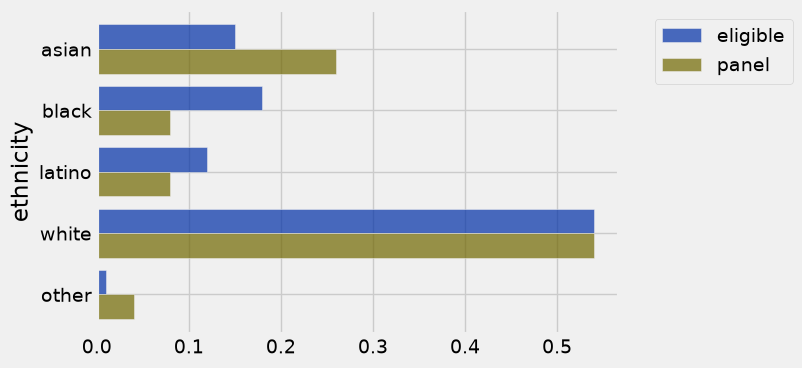

In [3]:
jury.barh('ethnicity')

In [4]:
model = make_array(.15, .18, .12, .54, .01)

In [5]:
simulated = sample_proportions(1453, model)
simulated

array([ 0.14108741,  0.18582244,  0.12663455,  0.53888507,  0.00757054])

In [6]:
jury_with_simulated = jury.with_column('simulated', simulated)
jury_with_simulated

ethnicity,eligible,panel,simulated
asian,0.15,0.26,0.141087
black,0.18,0.08,0.185822
latino,0.12,0.08,0.126635
white,0.54,0.54,0.538885
other,0.01,0.04,0.00757054


## We need a statistic

In [7]:
diffs = jury.column('panel')- jury.column('eligible')
jury_with_difference = jury.with_column('difference', diffs)
jury_with_difference

ethnicity,eligible,panel,difference
asian,0.15,0.26,0.11
black,0.18,0.08,-0.1
latino,0.12,0.08,-0.04
white,0.54,0.54,0
other,0.01,0.04,0.03


In [8]:
sum(jury_with_difference.column('difference'))

2.7755575615628914e-17

In [9]:
sum(jury_with_difference.where('difference', are.above(0)).column('difference'))

0.14000000000000001

In [10]:
sum(abs(jury_with_difference.column('difference'))) / 2

0.14000000000000001

## The total variation distance (TVD)

In [11]:
def tvd(dist1, dist2):
    return sum(abs(dist1-dist2)) / 2

In [12]:
obsvd_tvd = tvd(jury.column('panel'), jury.column('eligible'))
obsvd_tvd

0.14000000000000001

In [13]:
simulated_tvd = tvd(sample_proportions(1453, model), jury.column('eligible'))
simulated_tvd

0.010061940812112879

## model vs alternative viewpoint

In [14]:
def simulate_tvd():
    return tvd(sample_proportions(1453, model), model)

tvds = make_array()

num_simulations = 10000

for i in np.arange(num_simulations):
    new_tvd = simulate_tvd()
    tvds = np.append(tvds, new_tvd)

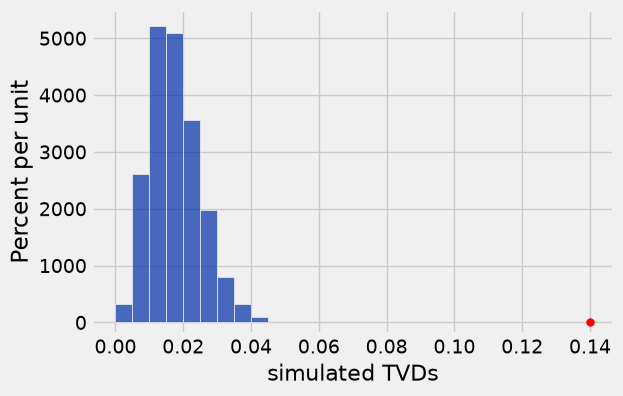

In [16]:
title = 'simulated TVDs'
bins = np.arange(0, .05, .005)

Table().with_columns(title, tvds).hist(bins = bins)

## plotting details
plt.ylim(-2, 55)
plt.scatter(obsvd_tvd, 0, color = 'red', s = 30)